In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("../data/processed/customerIQ_customer_churn_features.csv")
df.head()

,customer_id,age,gender,location,tenure_months,monthly_spend,total_spend,login_frequency,support_tickets,product_usage,subscription_type,payment_method,discount_used,churn,customer_lifetime_value,average_monthly_spend,usage_per_month,support_ticket_rate,age_group,tenure_group
0,C100000,56.0,Female,Mumbai,40,1008.23,43296.89,20.0,1,68.0,Monthly,Debit Card,1,0,45804.53,1082.422250,1.700000,0.025000,51+,25+ months
1,C100001,69.0,Male,Delhi,31,1716.53,52968.01,20.0,3,87.0,Monthly,UPI,0,0,92328.73,1708.645484,2.806452,0.096774,51+,25+ months
2,C100002,46.0,Female,Mumbai,65,1035.82,72203.52,23.0,7,88.0,Monthly,Wallet,1,0,83848.62,1110.823385,1.353846,0.107692,36-50,25+ months
3,C100003,32.0,Male,Other,39,2622.21,107971.82,13.0,1,68.0,Annual,UPI,0,0,126076.33,2768.508205,1.743590,0.025641,26-35,25+ months
4,C100004,60.0,Male,Pune,24,2117.73,49767.32,4.0,2,80.0,Monthly,Debit Card,1,0,72619.73,2073.638333,3.333333,0.083333,51+,13-24 months


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.columns.tolist())

Rows: 10000
Columns: 20
['customer_id', 'age', 'gender', 'location', 'tenure_months', 'monthly_spend', 'total_spend', 'login_frequency', 'support_tickets', 'product_usage', 'subscription_type', 'payment_method', 'discount_used', 'churn', 'customer_lifetime_value', 'average_monthly_spend', 'usage_per_month', 'support_ticket_rate', 'age_group', 'tenure_group']


In [5]:
clustering_features = [
    "tenure_months",
    "monthly_spend",
    "login_frequency",
    "support_tickets",
    "product_usage",
    "customer_lifetime_value"
]

X_cluster = df[clustering_features]
X_cluster.head()

,tenure_months,monthly_spend,login_frequency,support_tickets,product_usage,customer_lifetime_value
0,40,1008.23,20.0,1,68.0,45804.53
1,31,1716.53,20.0,3,87.0,92328.73
2,65,1035.82,23.0,7,88.0,83848.62
3,39,2622.21,13.0,1,68.0,126076.33
4,24,2117.73,4.0,2,80.0,72619.73


In [6]:
print("Clustering data shape:", X_cluster.shape)
print(X_cluster.isnull().sum())

Clustering data shape: (10000, 6)
tenure_months              0
monthly_spend              0
login_frequency            0
support_tickets            0
product_usage              0
customer_lifetime_value    0
dtype: int64


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (10000, 6)


In [8]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[46825.46360098646, 41518.941968540326, 37695.678972582544, 34817.171265889854, 32489.96413077508, 30686.483567510008, 29142.73438923223, 27894.436640682616, 26671.63657405968]


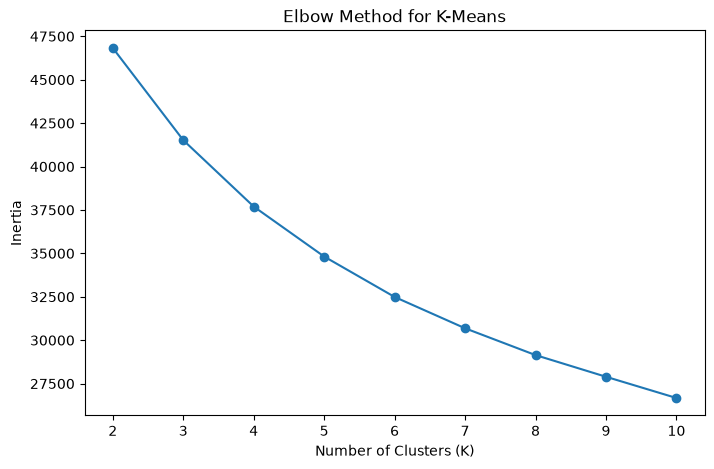

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(range(2, 11))
plt.show()

In [10]:
optimal_k = 4
print("Selected K:", optimal_k)

Selected K: 4


In [11]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed")

K-Means clustering completed


In [12]:
df["cluster"] = cluster_labels

df[["customer_id", "cluster"]].head()

,customer_id,cluster
0,C100000,0
1,C100001,1
2,C100002,0
3,C100003,2
4,C100004,3


In [13]:
cluster_counts = df["cluster"].value_counts().sort_index()
cluster_counts

cluster
0    2262
1    2593
2    2772
3    2373
Name: count, dtype: int64

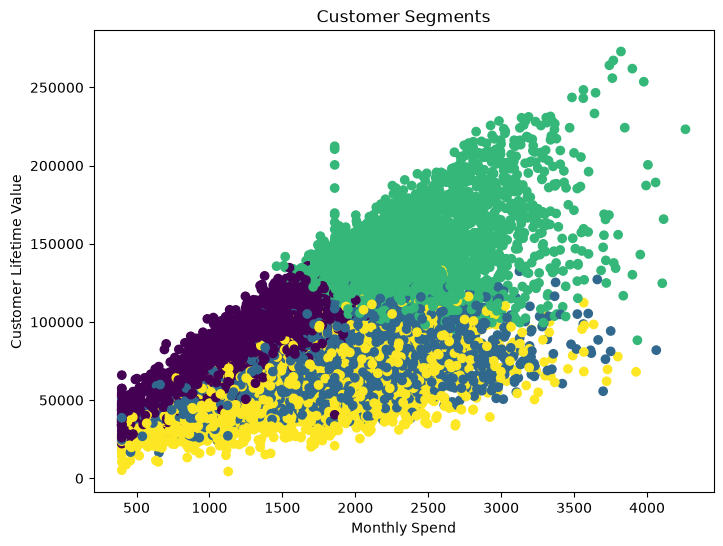

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["monthly_spend"],
    df["customer_lifetime_value"],
    c=df["cluster"]
)
plt.xlabel("Monthly Spend")
plt.ylabel("Customer Lifetime Value")
plt.title("Customer Segments")
plt.show()

In [15]:
cluster_profiles = df.groupby("cluster")[
    [
        "tenure_months",
        "monthly_spend",
        "login_frequency",
        "support_tickets",
        "product_usage",
        "customer_lifetime_value",
        "churn"
    ]
].mean()

cluster_profiles

,tenure_months,monthly_spend,login_frequency,support_tickets,product_usage,customer_lifetime_value,churn
cluster,,,,,,,
0,52.438550,1291.074889,13.944739,2.081344,73.843501,85748.809505,0.015031
1,18.159275,1910.929155,19.113768,1.948322,83.027381,72553.632160,0.020440
2,53.817460,2400.211710,15.298701,2.180736,72.924242,144961.545685,0.014791
3,21.282764,1735.807261,10.584492,2.854614,53.391909,60656.818862,0.054362


In [16]:
for cluster in cluster_profiles.index:
    print("Cluster:", cluster)
    print("Average Tenure:", round(cluster_profiles.loc[cluster, "tenure_months"], 2))
    print("Average Monthly Spend:", round(cluster_profiles.loc[cluster, "monthly_spend"], 2))
    print("Average Login Frequency:", round(cluster_profiles.loc[cluster, "login_frequency"], 2))
    print("Average Support Tickets:", round(cluster_profiles.loc[cluster, "support_tickets"], 2))
    print("Average Product Usage:", round(cluster_profiles.loc[cluster, "product_usage"], 2))
    print("Average CLV:", round(cluster_profiles.loc[cluster, "customer_lifetime_value"], 2))
    print("Churn Rate:", round(cluster_profiles.loc[cluster, "churn"] * 100, 2), "%")
    print()

Cluster: 0
Average Tenure: 52.44
Average Monthly Spend: 1291.07
Average Login Frequency: 13.94
Average Support Tickets: 2.08
Average Product Usage: 73.84
Average CLV: 85748.81
Churn Rate: 1.5 %

Cluster: 1
Average Tenure: 18.16
Average Monthly Spend: 1910.93
Average Login Frequency: 19.11
Average Support Tickets: 1.95
Average Product Usage: 83.03
Average CLV: 72553.63
Churn Rate: 2.04 %

Cluster: 2
Average Tenure: 53.82
Average Monthly Spend: 2400.21
Average Login Frequency: 15.3
Average Support Tickets: 2.18
Average Product Usage: 72.92
Average CLV: 144961.55
Churn Rate: 1.48 %

Cluster: 3
Average Tenure: 21.28
Average Monthly Spend: 1735.81
Average Login Frequency: 10.58
Average Support Tickets: 2.85
Average Product Usage: 53.39
Average CLV: 60656.82
Churn Rate: 5.44 %

